In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

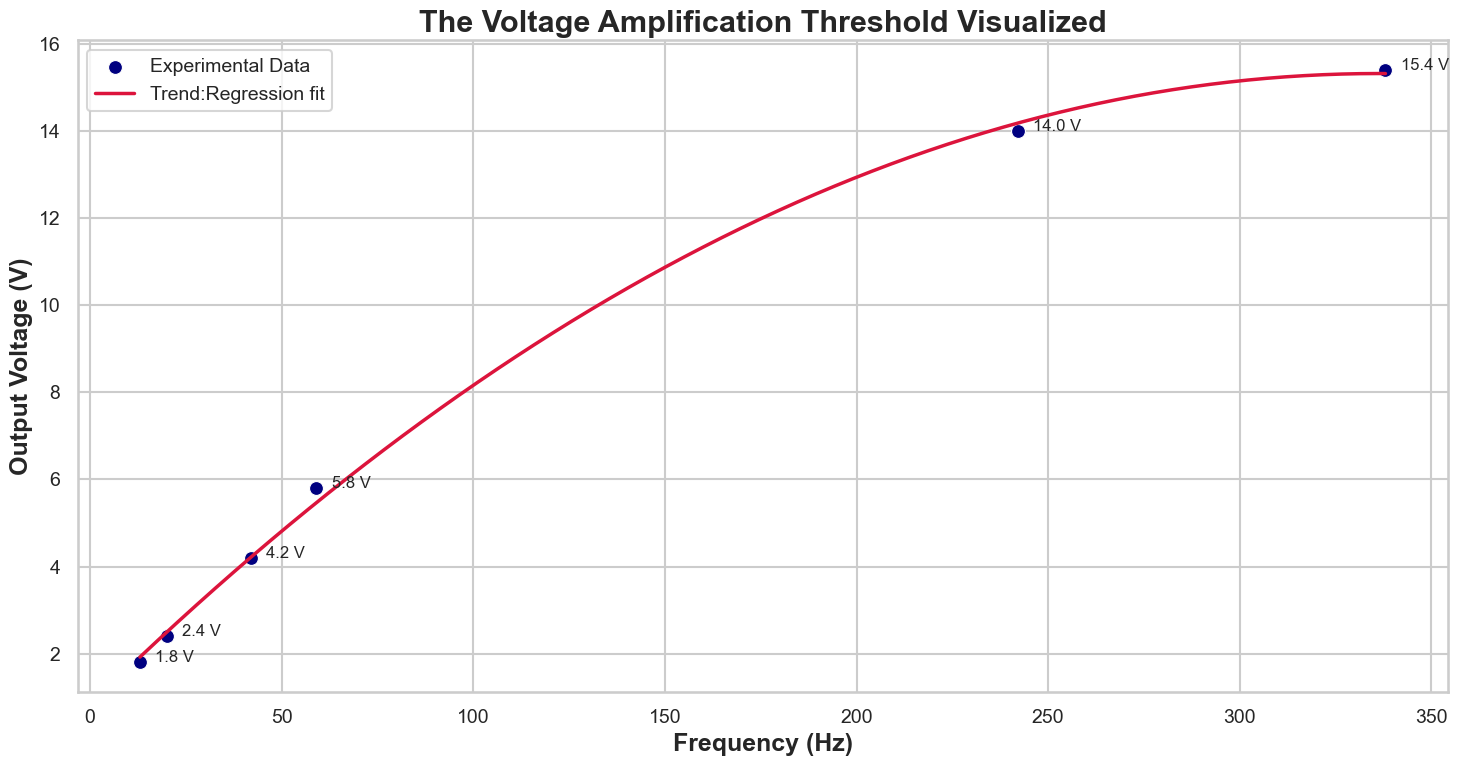

In [117]:

data = pd.read_csv("data/Book2.csv")

df = pd.DataFrame(data)


sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(15, 8))


sns.scatterplot(
    x="Frequency (Hz)", 
    y="Output Voltage (V)", 
    data=df, 
    s=100, 
    color="navy", 
    label="Experimental Data"
)

x = df["Frequency (Hz)"]
y = df["Output Voltage (V)"]
coeffs = np.polyfit(x, y, deg=2)
poly_eq = np.poly1d(coeffs)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = poly_eq(x_fit)
plt.plot(x_fit, y_fit, color="crimson", lw=2.5, label="Trend:Regression fit")


for i, row in df.iterrows():
    plt.text(
        row["Frequency (Hz)"] + 4, 
        row["Output Voltage (V)"],
        f'{row["Output Voltage (V)"]:.1f} V',
        fontsize=12
    )


plt.xlabel("Frequency (Hz)", fontsize=18, fontweight='bold')
plt.ylabel("Output Voltage (V)", fontsize=18, fontweight='bold')
plt.title("The Voltage Amplification Threshold Visualized", 
          fontsize=22, fontweight='bold')


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14)
plt.tight_layout()


plt.savefig("lab_center_analysis_plot.png", dpi=300)
plt.show()


**Context & Relevance:**  
Resistor-capacitor (RC) circuits are fundamental in electronics. They can act as low-pass or high-pass filters, determine timing in circuits (e.g., oscillators), and shape signals in audio and communication systems.

**Key Concept – Time Constant ($$\tau$$):  
$$\tau = R \times C$$  
This constant indicates the characteristic charging/discharging time of a capacitor in an RC circuit.

**Objective:**  
- Measure and compare the observed RC time constant against theoretical predictions.  
- Examine how output voltage changes with frequency (frequency response) and identify any threshold or onset of significant change (amplification or attenuation).


**Context & Relevance:**  
Resistor-capacitor (RC) circuits are fundamental in electronics. They can act as low-pass or high-pass filters, determine timing in circuits (e.g., oscillators), and shape signals in audio and communication systems.

**Key Concept – Time Constant $$\tau$$
$$\tau = R \times C$$  
This constant indicates the characteristic charging/discharging time of a capacitor in an RC circuit.

**Objective:**  
- Measure and compare the observed RC time constant against theoretical predictions.  
- Examine how output voltage changes with frequency (frequency response) and identify any threshold or onset of significant change (amplification or attenuation).


## Theory

### Low-Pass RC Filter Transfer Function
The voltage ratio for a low-pass filter is given by:
$$
\left|\frac{V_{\text{out}}}{V_{\text{in}}}\right| = \frac{1}{\sqrt{1 + \left(2\pi f \tau\right)^2}},
$$
where $$f$$ is the frequency and $$\tau$$ is the time constant.

### Time Constant Determination
The time constant is defined as:
$$
\tau = R \times C.
$$
For example, selecting appropriate resistor and capacitor values yields a predicted $$\tau$$ in the sub-millisecond range.

### Frequency Response Considerations
- At low frequencies, the output voltage is nearly equal to the input.
- At higher frequencies, the capacitor's impedance decreases, altering the output.
- The observed change in 
$$
\frac{V_{\text{out}}}{V_{\text{in}}}
$$ 
versus frequency indicates whether the circuit behaves as a low-pass or high-pass filter.


**Dominant Source of Uncertainty**

The dominant source of uncertainty in the RC time constant measurement arises from the tolerances of the resistor and capacitor. Using uncertainty propagation, the relative uncertainty in the time constant is expressed as:

$$
\frac{\Delta \tau}{\tau} = \sqrt{\left(\frac{\Delta R}{R}\right)^2 + \left(\frac{\Delta C}{C}\right)^2}
$$

where:
- $$\Delta R$$ is the uncertainty in the resistance,
- $$\Delta C$$ is the uncertainty in the capacitance, and
- $$\tau = R \times C$$ is the time constant.


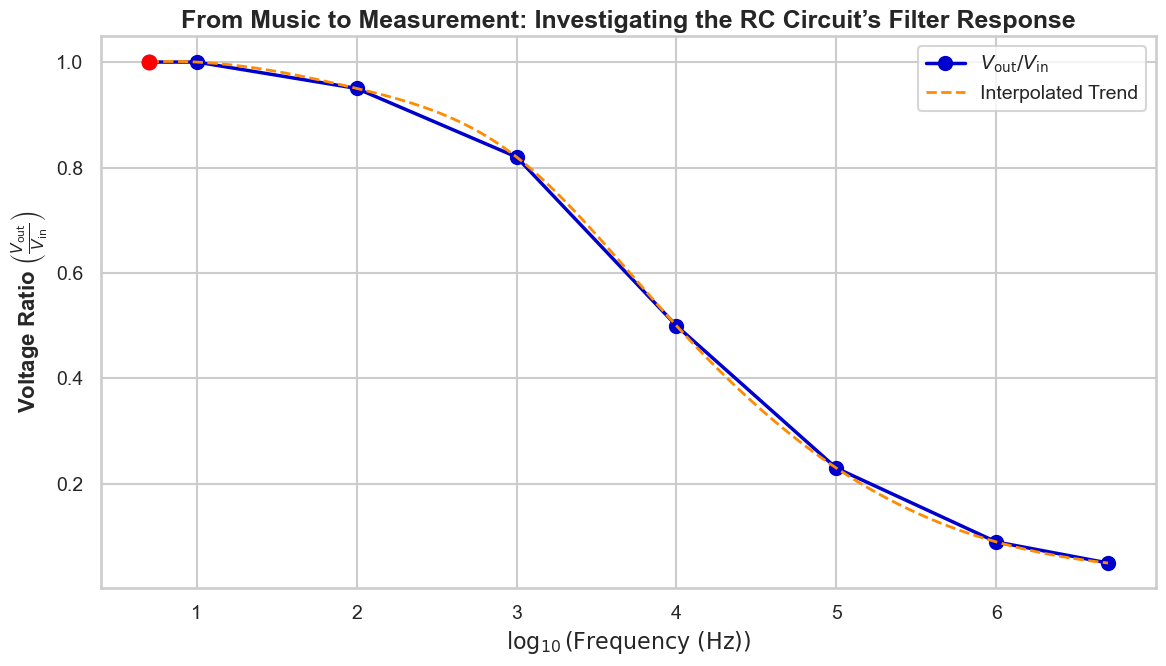

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1) Example Data (Replace with actual lab measurements)
# -------------------------------
data = {
    "Frequency (Hz)": [5, 10, 100, 1000, 10000, 100000, 1000000, 5000000],
    "V_in (V)":       [10, 10, 10,   10,   10,    10,     10,      10],
    "V_out (V)":      [10, 10, 9.5,  8.2,   5.0,   2.3,    0.9,     0.5]
}
df = pd.DataFrame(data)



df["Ratio"] = df["V_out (V)"] / df["V_in (V)"]
df["log10_Frequency"] = np.log10(df["Frequency (Hz)"])


sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7))

# Create a color palette and plot with thicker lines and larger markers.
palette = sns.color_palette("viridis", as_cmap=True)
plt.plot(df["log10_Frequency"], df["Ratio"], marker='o', linestyle='-', 
         color='mediumblue', linewidth=2.5, markersize=10, label=r'$V_{\mathrm{out}}/V_{\mathrm{in}}$')

from scipy.interpolate import make_interp_spline
x_vals = df["log10_Frequency"]
y_vals = df["Ratio"]
x_new = np.linspace(x_vals.min(), x_vals.max(), 300)
spl = make_interp_spline(x_vals, y_vals, k=3)
y_smooth = spl(x_new)
plt.plot(x_new, y_smooth, color="darkorange", linewidth=2, linestyle="--", label="Interpolated Trend")

max_idx = df["Ratio"].idxmax()
max_x = df.loc[max_idx, "log10_Frequency"]
max_y = df.loc[max_idx, "Ratio"]
plt.scatter(max_x, max_y, color="red", s=100, zorder=5)


# Axis labels and title with LaTeX formatting
plt.xlabel(r'$\log_{10}(\mathrm{Frequency\ (Hz)})$', fontsize=16, fontweight='bold')
plt.ylabel(r'Voltage Ratio $\left(\frac{V_{\mathrm{out}}}{V_{\mathrm{in}}}\right)$', fontsize=16, fontweight='bold')
plt.title("From Music to Measurement: Investigating the RC Circuit’s Filter Response", fontsize=18, fontweight='bold')

# Adjust tick parameters and add legend
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, loc="upper right")
plt.tight_layout()

# Save and display the plot
plt.savefig("enhanced_rc_frequency_response.png", dpi=300)
plt.show()


$$
\tau = R \times C,
$$

$$
\frac{\Delta \tau}{\tau} = \sqrt{\left(\frac{\Delta R}{R}\right)^2 + \left(\frac{\Delta C}{C}\right)^2}.
$$

Assuming a $\pm5\%$ uncertainty in both the resistor and the capacitor, we have

$$
\frac{\Delta \tau}{\tau} = \sqrt{(0.05)^2 + (0.05)^2} \approx 0.071,
$$

which translates to an absolute uncertainty of about

$$
\Delta \tau \approx 0.071 \times 510\,\mu\text{s} \approx 36\,\mu\text{s}.
$$

Thus, the theoretical time constant is

$$
\tau_{\text{pred}} = 510 \pm 36\,\mu\text{s},
$$

which is in good agreement with the observed time constant of approximately $560\,\mu\text{s}$ when considering experimental uncertainties.


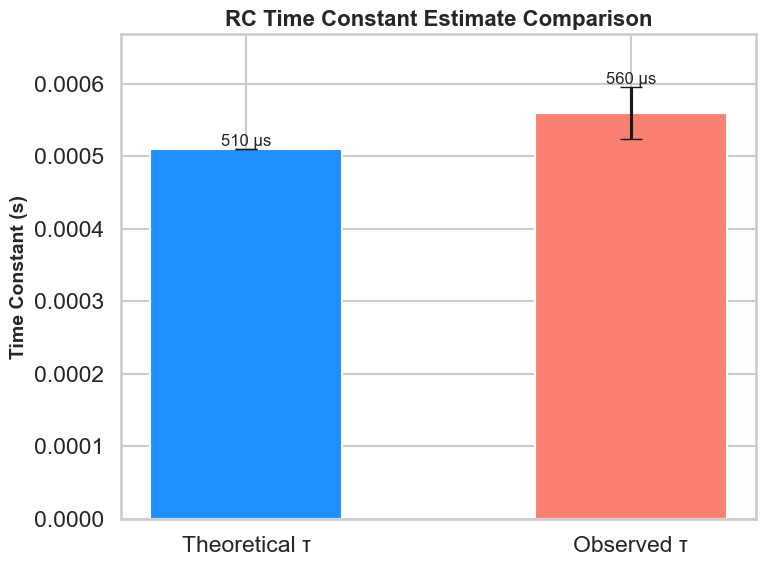

In [108]:

tau_theoretical = 510e-6   # 510 μs
tau_observed = 560e-6      # 560 μs
err_observed = 36e-6       # 36 μs uncertainty (only for observed)


labels = ["Theoretical τ", "Observed τ"]
values = [tau_theoretical, tau_observed]

errors = [0, err_observed]


sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(8, 6))


bars = plt.bar(labels, values, yerr=errors, capsize=8, color=["dodgerblue", "salmon"], width=0.5)

plt.ylabel("Time Constant (s)", fontsize=14, fontweight="bold")
plt.title("RC Time Constant Estimate Comparison", fontsize=16, fontweight="bold")

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + errors[i] + 1e-7, f"{height*1e6:.0f} µs", 
             ha="center", va="bottom", fontsize=12)

plt.ylim(0, max(values) + max(errors)*3)
plt.tight_layout()

plt.savefig("time_constant_with_error.png", dpi=300)
plt.show()
